# FashionMNIST Conditional DiT + Rectified Flow diagnostics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HisameOgasahara/deep-learning-diagnostics-and-improvement/blob/main/colab/DiT/fashion_mnist_conditional_dit_rectified_flow_diagnostics.ipynb)


이 노트북은 **학습 상태 → timestep별 velocity field → DiT representation → local generative geometry → sampling trajectory → 최종 생성분포** 순서로 진단합니다.

메인 비교축은 생성 시간 \(t\), 보조 비교축은 training checkpoint, sampling 비교는 Euler / Heun / RK4와 matched NFE입니다.

## 0. 환경 준비

In [1]:
!pip -q install datasets scikit-learn pandas matplotlib
RAW = "https://raw.githubusercontent.com/HisameOgasahara/deep-learning-diagnostics-and-improvement/main/colab/DiT"
!wget -q -O dit_rf_model.py "$RAW/dit_rf_model.py"
!wget -q -O dit_rf_train.py "$RAW/dit_rf_train.py"
!wget -q -O dit_rf_diagnostics.py "$RAW/dit_rf_diagnostics.py"

from pathlib import Path
import random, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from datasets import load_dataset

from dit_rf_model import MiniConditionalDiT
from dit_rf_train import train_dit, train_feature_encoder
from dit_rf_diagnostics import (
    velocity_diagnostics, divergence_diagnostics,
    representation_grid, attention_locality_grid,
    jacobian_spectrum_over_time, sample_flow,
    trajectory_metrics, generated_distribution_summary,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device, torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

cuda Tesla T4


## 1. FashionMNIST — Hugging Face 우선 다운로드

README.md:   0%|          | 0.00/9.02k [00:00<?, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 30.9MB            

fashion_mnist/train-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

fashion_mnist/test-00000-of-00001.parque(…): reconstructing file:   0%|          |  0.00B / 5.18MB            

fashion_mnist/test-00000-of-00001.parque(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

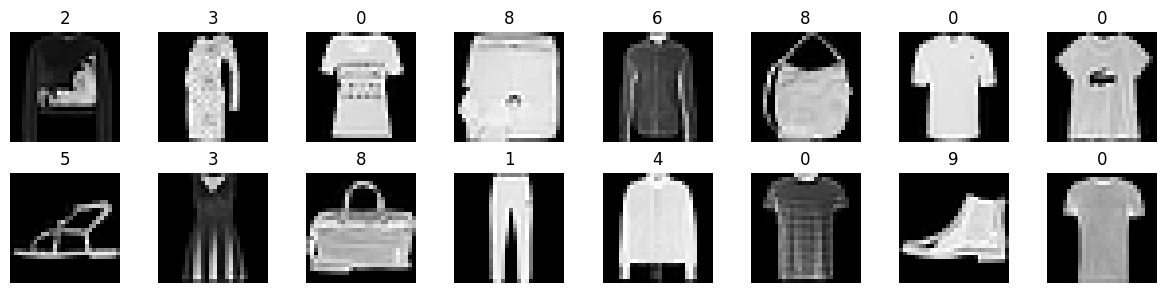

55000 5000 10000


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

class HFDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, i):
        item = self.dataset[i]
        return transform(item["image"]), int(item["label"])

raw = load_dataset("zalando-datasets/fashion_mnist")
split = raw["train"].train_test_split(test_size=5000, seed=SEED)
train_set = HFDataset(split["train"])
val_set = HFDataset(split["test"])
test_set = HFDataset(raw["test"])

def make_loader(dataset, shuffle):
    return DataLoader(
        dataset, batch_size=256, shuffle=shuffle,
        num_workers=2, pin_memory=True, persistent_workers=True,
    )

train_loader = make_loader(train_set, True)
val_loader = make_loader(val_set, False)
test_loader = make_loader(test_set, False)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for ax, image, label in zip(axes.flat, images[:16], labels[:16]):
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(int(label)); ax.axis("off")
plt.tight_layout(); plt.show()
print(len(train_set), len(val_set), len(test_set))

## 2. Mini conditional DiT + Rectified Flow

\[
x_t=(1-t)x_0+t x_1,\qquad v^\star=x_1-x_0
\]

pixel-space mini-DiT: patch 4, dim 192, depth 6, heads 6, class/time conditioning.

In [3]:
model = MiniConditionalDiT(
    patch_size=4, dim=192, depth=6, heads=6, mlp_ratio=4,
).to(device)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

parameters: 4,386,256


## 3. 50 epoch 학습 + timestep-binned loss

전체 loss와 함께 \(t\) 10개 구간의 loss를 매 epoch 기록합니다. checkpoint는 0/10/25/50 epoch입니다.

epoch 01/50 | flow loss 0.64419
epoch 02/50 | flow loss 0.36865
epoch 03/50 | flow loss 0.31514
epoch 04/50 | flow loss 0.29127
epoch 05/50 | flow loss 0.27484
epoch 06/50 | flow loss 0.26479
epoch 07/50 | flow loss 0.25775
epoch 08/50 | flow loss 0.25207
epoch 09/50 | flow loss 0.24808
epoch 10/50 | flow loss 0.24324
epoch 11/50 | flow loss 0.24153
epoch 12/50 | flow loss 0.23879
epoch 13/50 | flow loss 0.23639
epoch 14/50 | flow loss 0.23376
epoch 15/50 | flow loss 0.23168
epoch 16/50 | flow loss 0.23077
epoch 17/50 | flow loss 0.22971
epoch 18/50 | flow loss 0.22832
epoch 19/50 | flow loss 0.22702
epoch 20/50 | flow loss 0.22581
epoch 21/50 | flow loss 0.22539
epoch 22/50 | flow loss 0.22468
epoch 23/50 | flow loss 0.22214
epoch 24/50 | flow loss 0.22222
epoch 25/50 | flow loss 0.22046
epoch 26/50 | flow loss 0.22044
epoch 27/50 | flow loss 0.22021
epoch 28/50 | flow loss 0.21935
epoch 29/50 | flow loss 0.21822
epoch 30/50 | flow loss 0.21716
epoch 31/50 | flow loss 0.21717
epoch 32

,epoch,train_flow_loss,lr
45,46,0.211249,4.712526e-06
46,47,0.209635,2.656912e-06
47,48,0.210440,1.182795e-06
48,49,0.210176,2.959907e-07
49,50,0.209927,0.000000e+00


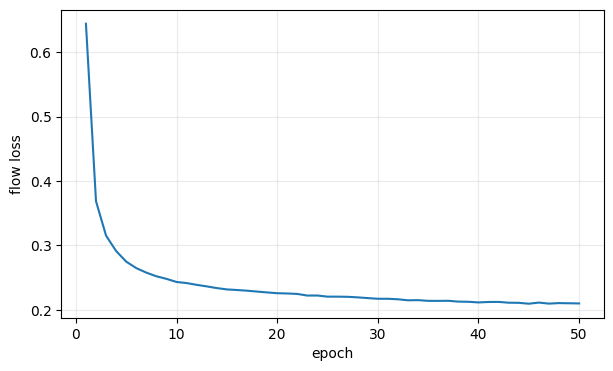

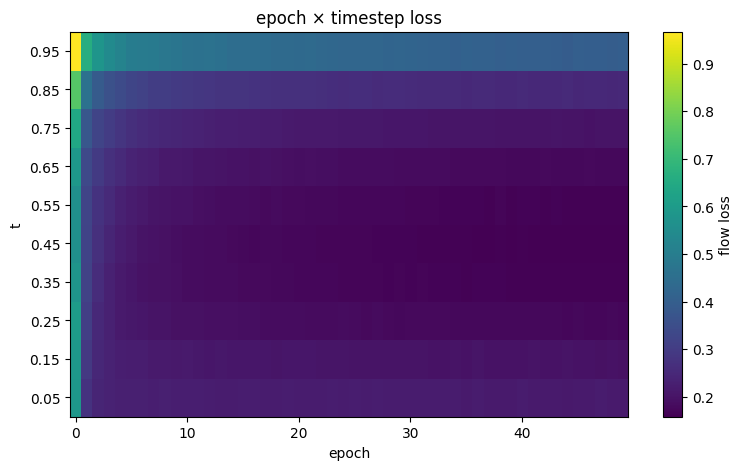

In [4]:
ARTIFACT_DIR = Path("/content/dit_rf_artifacts")
history_df, timestep_loss_df = train_dit(
    model, train_loader, device, ARTIFACT_DIR,
    epochs=50, checkpoint_epochs=(0, 10, 25, 50),
)

display(history_df.tail())
plt.figure(figsize=(7,4))
plt.plot(history_df.epoch, history_df.train_flow_loss)
plt.xlabel("epoch"); plt.ylabel("flow loss"); plt.grid(alpha=.25); plt.show()

pivot = timestep_loss_df.pivot(index="epoch", columns="t_mid", values="flow_loss")
plt.figure(figsize=(9,5))
plt.imshow(pivot.T, aspect="auto", origin="lower")
plt.colorbar(label="flow loss")
plt.yticks(range(len(pivot.columns)), [f"{x:.2f}" for x in pivot.columns])
plt.xlabel("epoch"); plt.ylabel("t"); plt.title("epoch × timestep loss"); plt.show()

## 4. Velocity field diagnostics

각 \(t\)에서 velocity MSE, predicted/target norm, target–prediction cosine을 봅니다.  
**참고:** ICML 2025 *Elucidating Flow Matching ODE Dynamics via Data Geometry and Denoisers*.

,t,velocity_mse,pred_velocity_norm,target_velocity_norm,velocity_cosine,velocity_mse_std
0,0.05,0.219351,33.766191,36.325341,0.932357,0.119540
1,0.15,0.197582,34.199752,36.305159,0.939325,0.104858
2,0.25,0.174122,34.382522,36.312483,0.946635,0.086171
3,0.35,0.164027,34.507163,36.349015,0.949766,0.081870
4,0.45,0.161513,34.554852,36.329326,0.950251,0.083193
5,0.55,0.165458,34.493977,36.348698,0.948821,0.086651
6,0.65,0.175877,34.379195,36.305951,0.945014,0.092816
7,0.75,0.199986,34.043304,36.329488,0.936933,0.100460
8,0.85,0.249006,33.521833,36.319209,0.920521,0.110937
9,0.95,0.371830,31.952581,36.320580,0.878254,0.123658


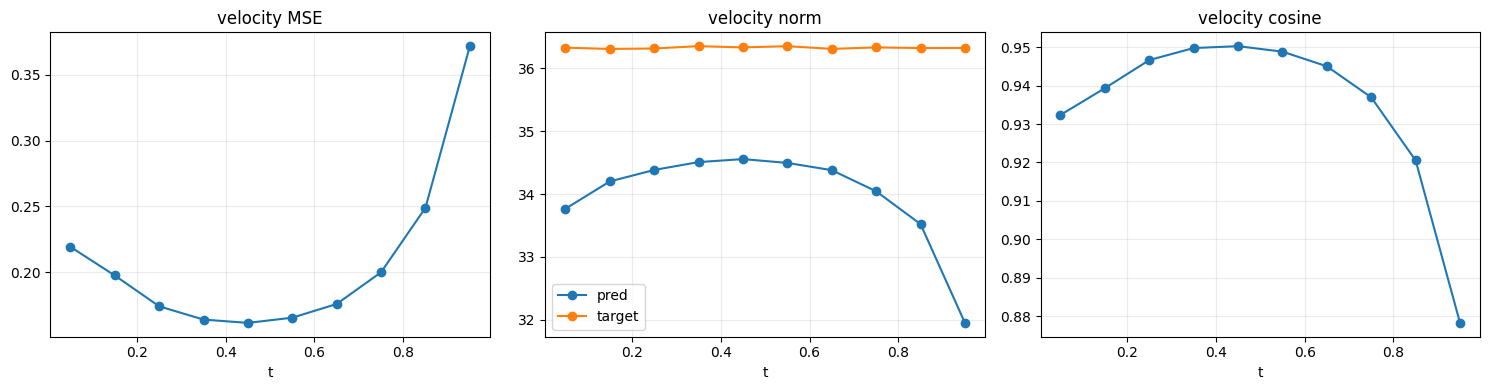

In [5]:
T_VALUES = np.linspace(0.05, 0.95, 10)
model.load_state_dict(torch.load(ARTIFACT_DIR/"dit_epoch_50.pt", map_location=device))

velocity_df = velocity_diagnostics(model, val_loader, device, T_VALUES)
display(velocity_df)

fig, axes = plt.subplots(1,3,figsize=(15,4))
axes[0].plot(velocity_df.t, velocity_df.velocity_mse, marker="o")
axes[0].set_title("velocity MSE")
axes[1].plot(velocity_df.t, velocity_df.pred_velocity_norm, marker="o", label="pred")
axes[1].plot(velocity_df.t, velocity_df.target_velocity_norm, marker="o", label="target")
axes[1].legend(); axes[1].set_title("velocity norm")
axes[2].plot(velocity_df.t, velocity_df.velocity_cosine, marker="o")
axes[2].set_title("velocity cosine")
for ax in axes: ax.set_xlabel("t"); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

## 5. Velocity divergence

\[
\operatorname{div}v_\theta(x,t)=\operatorname{tr}D_xv_\theta(x,t)
\]

Hutchinson estimator로 timestep별 field 수축/팽창을 봅니다.  
**참고:** ICML 2025 *Improving Flow Matching by Aligning Flow Divergence*.

,t,divergence_mean,divergence_abs_mean,divergence_std
0,0.05,-814.735018,814.735018,4.663476
1,0.15,-897.246505,897.246505,12.389352
2,0.25,-999.580436,999.580436,17.708182
3,0.35,-1137.036911,1137.036911,24.578909
4,0.45,-1322.851440,1322.851440,42.482240
5,0.55,-1583.158139,1583.158139,65.298193
6,0.65,-1987.549682,1987.549682,116.680791
7,0.75,-2666.637765,2666.637765,208.423748
8,0.85,-4138.890678,4138.890678,450.266697
9,0.95,-10140.686022,10140.686022,1666.290021


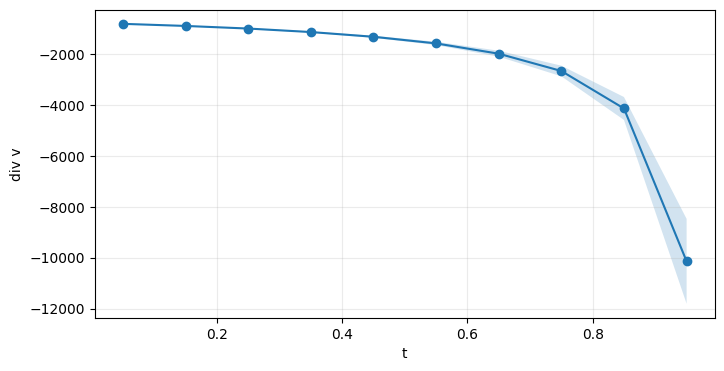

In [6]:
divergence_df = divergence_diagnostics(
    model, val_loader, device, T_VALUES, max_batches=2, probes=1,
)
display(divergence_df)

plt.figure(figsize=(8,4))
plt.plot(divergence_df.t, divergence_df.divergence_mean, marker="o")
plt.fill_between(
    divergence_df.t,
    divergence_df.divergence_mean-divergence_df.divergence_std,
    divergence_df.divergence_mean+divergence_df.divergence_std,
    alpha=.2,
)
plt.xlabel("t"); plt.ylabel("div v"); plt.grid(alpha=.25); plt.show()

## 6. Representation dynamics — layer × timestep linear probe

어느 생성 단계와 어느 DiT block에서 class semantics가 선형적으로 읽히는지 봅니다.  
**참고:** NeurIPS 2025 *Understanding Representation Dynamics of Diffusion Models via Low-Dimensional Modeling*.

,t,layer,probe_accuracy
0,0.1,block_1,1.0
1,0.1,block_2,1.0
2,0.1,block_3,1.0
3,0.1,block_4,1.0
4,0.1,block_5,1.0
5,0.1,block_6,1.0
6,0.3,block_1,1.0
7,0.3,block_2,1.0
8,0.3,block_3,1.0
9,0.3,block_4,1.0


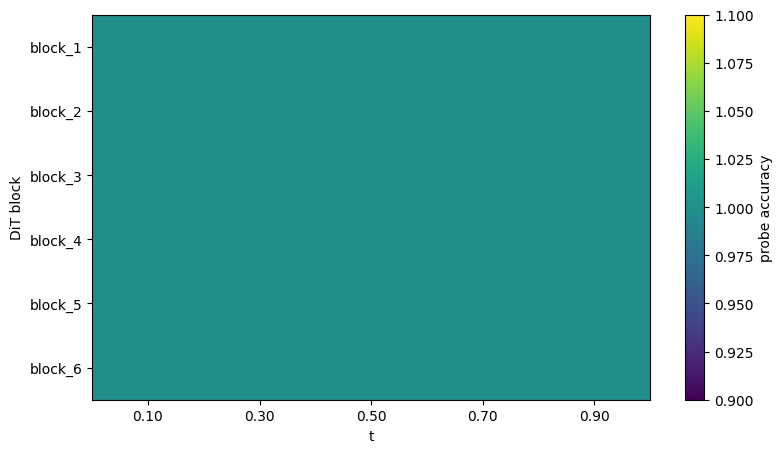

In [7]:
REP_T = np.linspace(0.1, 0.9, 5)
probe_df, subspace_df = representation_grid(
    model, train_loader, val_loader, device, REP_T,
    max_train_samples=3000, max_val_samples=2000, subspace_rank=8,
)
display(probe_df.head(12))

heat = probe_df.pivot(index="layer", columns="t", values="probe_accuracy")
plt.figure(figsize=(9,5)); plt.imshow(heat.values, aspect="auto")
plt.colorbar(label="probe accuracy")
plt.xticks(range(len(heat.columns)), [f"{x:.2f}" for x in heat.columns])
plt.yticks(range(len(heat.index)), heat.index)
plt.xlabel("t"); plt.ylabel("DiT block"); plt.show()

## 7. Class-subspace geometry

Class-wise PCA로 저차원 basis를 만들고, DiT feature variation이 자기 class dominant subspace에 놓이는 비율을 측정합니다.  
**참고:** NeurIPS 2025 representation-dynamics 논문의 class-subspace 관점.

,t,layer,class_subspace_energy
0,0.1,block_1,0.607577
1,0.1,block_2,0.653417
2,0.1,block_3,0.684697
3,0.1,block_4,0.729767
4,0.1,block_5,0.736187
5,0.1,block_6,0.772271
6,0.3,block_1,0.681833
7,0.3,block_2,0.734824
8,0.3,block_3,0.787157
9,0.3,block_4,0.814498


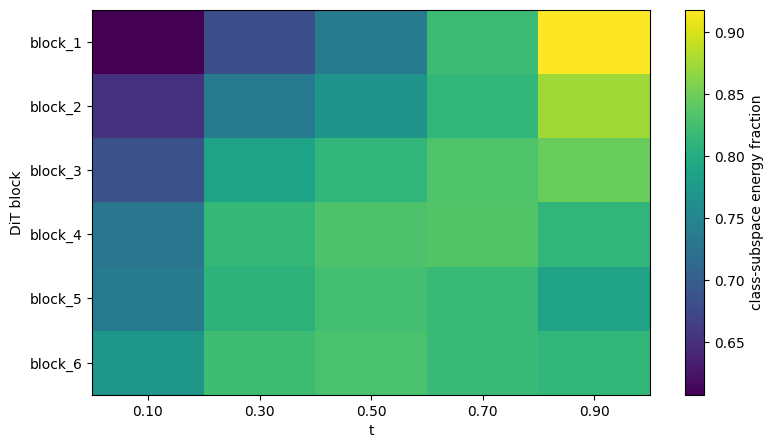

In [8]:
display(subspace_df.head(12))
heat = subspace_df.pivot(index="layer", columns="t", values="class_subspace_energy")
plt.figure(figsize=(9,5)); plt.imshow(heat.values, aspect="auto")
plt.colorbar(label="class-subspace energy fraction")
plt.xticks(range(len(heat.columns)), [f"{x:.2f}" for x in heat.columns])
plt.yticks(range(len(heat.index)), heat.index)
plt.xlabel("t"); plt.ylabel("DiT block"); plt.show()

## 8. Attention locality

Attention entropy, effective attended-token count, 평균 patch-grid attention distance를 layer × timestep으로 봅니다.

,t,layer,attention_entropy,mean_attention_distance,effective_attended_tokens
0,0.1,block_1,3.800521,3.541018,44.724465
1,0.1,block_2,3.548175,3.347820,34.749957
2,0.1,block_3,3.089617,3.060637,21.968666
3,0.1,block_4,2.841832,2.659854,17.147225
4,0.1,block_5,3.322667,3.127633,27.734320
5,0.1,block_6,2.486700,2.602007,12.021944
6,0.3,block_1,3.783910,3.504365,43.987700
7,0.3,block_2,3.384528,3.198746,29.504170
8,0.3,block_3,3.044300,2.950725,20.995358
9,0.3,block_4,2.511637,2.409809,12.325133


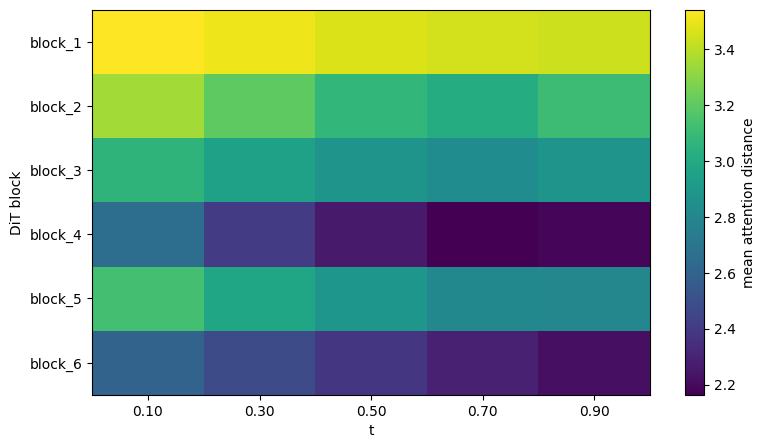

In [9]:
attention_df = attention_locality_grid(model, val_loader, device, REP_T, max_batches=2)
display(attention_df.head(12))

heat = attention_df.pivot(index="layer", columns="t", values="mean_attention_distance")
plt.figure(figsize=(9,5)); plt.imshow(heat.values, aspect="auto")
plt.colorbar(label="mean attention distance")
plt.xticks(range(len(heat.columns)), [f"{x:.2f}" for x in heat.columns])
plt.yticks(range(len(heat.index)), heat.index)
plt.xlabel("t"); plt.ylabel("DiT block"); plt.show()

## 9. Local generative geometry — velocity Jacobian spectrum

\[
J_v(x,t)=D_xv_\theta(x,t)
\]

대표 \(t=\{0.1,0.5,0.9\}\)에서 JVP/VJP subspace iteration으로 top singular values를 근사합니다.  
**참고:** NeurIPS 2024 *Understanding Generalizability... Hidden Gaussian Structure* 및 *Exploring Low-Dimensional Subspaces in Diffusion Models*.

,t,rank,singular_value
0,0.1,1,3.189311
1,0.1,2,1.118539
2,0.1,3,1.118368
3,0.1,4,1.115641
4,0.5,1,4.793177
5,0.5,2,3.815584
6,0.5,3,3.128255
7,0.5,4,2.226155
8,0.9,1,11.844461
9,0.9,2,11.371667


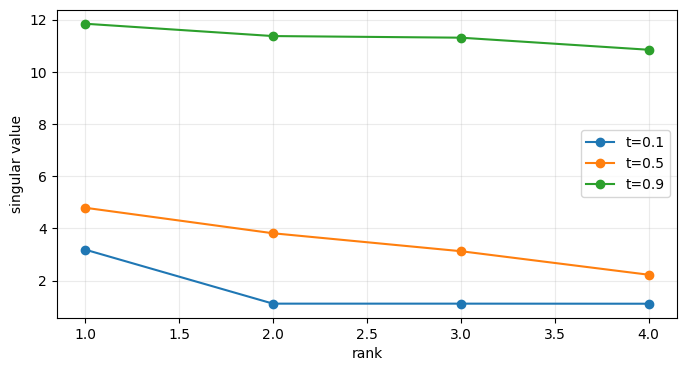

In [10]:
sample, label = val_set[0]
jacobian_df = jacobian_spectrum_over_time(
    model, sample, label, device, [0.1,0.5,0.9], rank=4, iterations=4,
)
display(jacobian_df)

plt.figure(figsize=(8,4))
for t, group in jacobian_df.groupby("t"):
    plt.plot(group["rank"], group.singular_value, marker="o", label=f"t={t}")
plt.xlabel("rank"); plt.ylabel("singular value"); plt.legend(); plt.grid(alpha=.25); plt.show()

## 10. Sampling trajectory dynamics

Path length, endpoint displacement, straightness ratio, consecutive velocity cosine을 봅니다.  
**참고:** ICML 2024 *On the Trajectory Regularity of ODE-based Diffusion Sampling*; NeurIPS 2024 *Optimal Flow Matching*.

,path_length,endpoint_displacement,straightness_ratio,mean_velocity_cosine
count,320.000000,320.000000,320.000000,320.000000
mean,33.464314,32.628757,1.025987,0.989932
std,1.857212,1.982316,0.009977,0.001405
min,28.044395,25.587397,1.012834,0.985561
25%,32.138859,31.268148,1.019461,0.988883
50%,33.592566,32.755774,1.023612,0.990004
75%,34.945580,34.174535,1.029518,0.991104
max,37.149796,36.573334,1.096024,0.992925


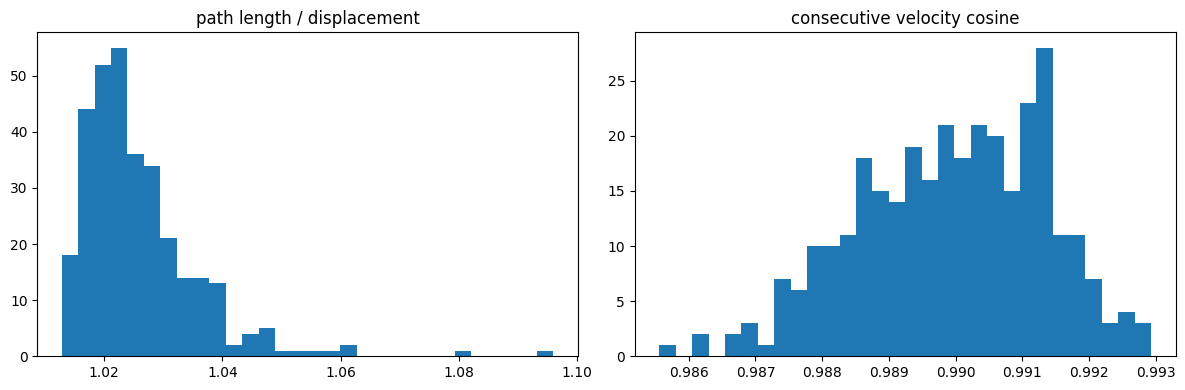

In [11]:
sample_labels = torch.arange(10).repeat_interleave(32)
baseline = sample_flow(model, sample_labels, device, solver="heun", nfe=32)
trajectory_df = trajectory_metrics(baseline)
display(trajectory_df.describe())

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].hist(trajectory_df.straightness_ratio, bins=30)
axes[0].set_title("path length / displacement")
axes[1].hist(trajectory_df.mean_velocity_cosine, bins=30)
axes[1].set_title("consecutive velocity cosine")
plt.tight_layout(); plt.show()

## 11. Solver × matched NFE

Euler / Heun / RK4를 동일 NFE 8/16/32에서 비교합니다. 목적은 최고 sampler 선정이 아니라 **같은 learned field를 다른 numerical condition에서 따라갈 때 trajectory 양상이 어떻게 변하는지** 보는 것입니다.

,solver,nfe,straightness_ratio,mean_velocity_cosine,path_length
0,euler,8,1.015735,0.993989,33.857643
1,euler,16,1.017950,0.997663,33.829704
2,euler,32,1.019974,0.999011,33.809425
3,heun,8,1.036140,0.942632,31.590231
4,heun,16,1.029766,0.976822,32.852333
5,heun,32,1.025937,0.989898,33.539967
6,rk4,8,1.014241,0.944165,31.828236
7,rk4,16,1.018534,0.978274,33.109310
8,rk4,32,1.020887,0.990296,33.492798


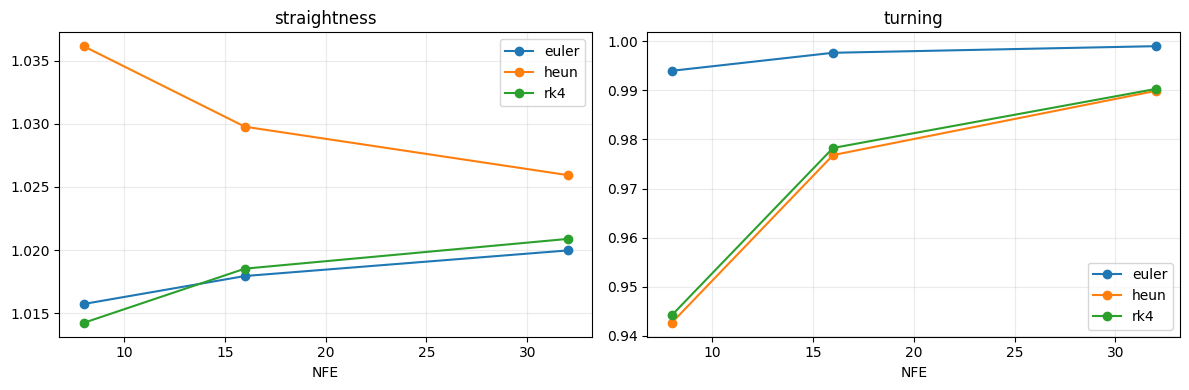

In [12]:
rows, sample_cache = [], {}
for solver in ["euler","heun","rk4"]:
    for nfe in [8,16,32]:
        result = sample_flow(model, sample_labels, device, solver=solver, nfe=nfe)
        metrics = trajectory_metrics(result)
        rows.append({
            "solver": solver, "nfe": nfe,
            "straightness_ratio": metrics.straightness_ratio.mean(),
            "mean_velocity_cosine": metrics.mean_velocity_cosine.mean(),
            "path_length": metrics.path_length.mean(),
        })
        sample_cache[(solver,nfe)] = result

solver_df = pd.DataFrame(rows)
display(solver_df)

fig, axes = plt.subplots(1,2,figsize=(12,4))
for solver, g in solver_df.groupby("solver"):
    axes[0].plot(g.nfe, g.straightness_ratio, marker="o", label=solver)
    axes[1].plot(g.nfe, g.mean_velocity_cosine, marker="o", label=solver)
for ax in axes: ax.set_xlabel("NFE"); ax.grid(alpha=.25); ax.legend()
axes[0].set_title("straightness"); axes[1].set_title("turning")
plt.tight_layout(); plt.show()

## 12. Frozen FashionMNIST feature encoder + final generated distribution

ImageNet Inception 대신 FashionMNIST-specific feature space에서 conditional class consistency와 Fréchet distance를 측정합니다.

encoder epoch 1/3 | train acc 0.8153
encoder epoch 2/3 | train acc 0.8845
encoder epoch 3/3 | train acc 0.9006
encoder validation accuracy: 0.9062


,solver,nfe,conditional_class_accuracy,feature_frechet_distance
0,euler,8,0.893750,37.333053
1,euler,16,0.925000,24.227759
2,euler,32,0.884375,20.486010
3,heun,8,0.896875,46.211488
4,heun,16,0.887500,28.283359
5,heun,32,0.890625,27.010736
6,rk4,8,0.890625,26.552741
7,rk4,16,0.896875,26.320601
8,rk4,32,0.906250,24.078940


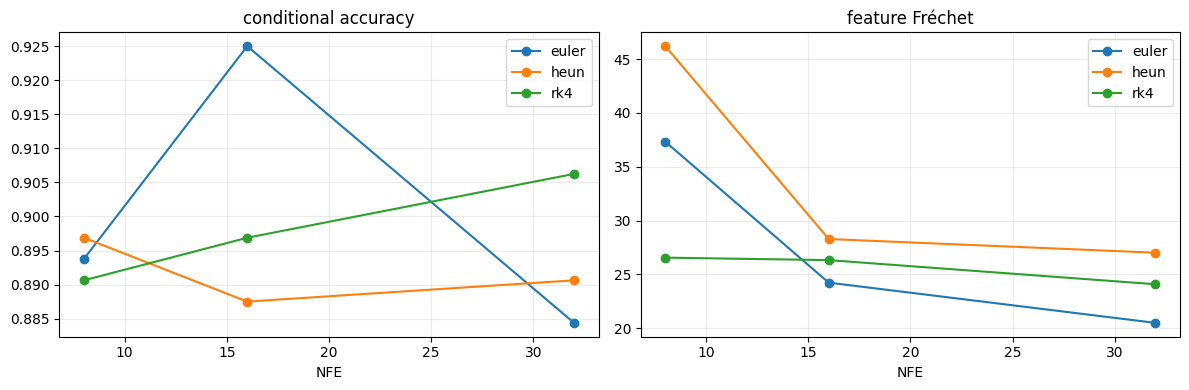

In [13]:
classifier = train_feature_encoder(train_loader, val_loader, device, epochs=3)

real_images = torch.cat([x for x,_ in list(test_loader)[:2]])[:len(sample_labels)]
rows = []
for (solver,nfe), result in sample_cache.items():
    summary = generated_distribution_summary(
        classifier, real_images, result.samples, sample_labels, device,
    )
    rows.append({"solver":solver, "nfe":nfe, **summary})

distribution_df = pd.DataFrame(rows)
display(distribution_df)

fig, axes = plt.subplots(1,2,figsize=(12,4))
for solver,g in distribution_df.groupby("solver"):
    axes[0].plot(g.nfe, g.conditional_class_accuracy, marker="o", label=solver)
    axes[1].plot(g.nfe, g.feature_frechet_distance, marker="o", label=solver)
for ax in axes: ax.set_xlabel("NFE"); ax.grid(alpha=.25); ax.legend()
axes[0].set_title("conditional accuracy"); axes[1].set_title("feature Fréchet")
plt.tight_layout(); plt.show()

## 13. 생성 샘플 확인

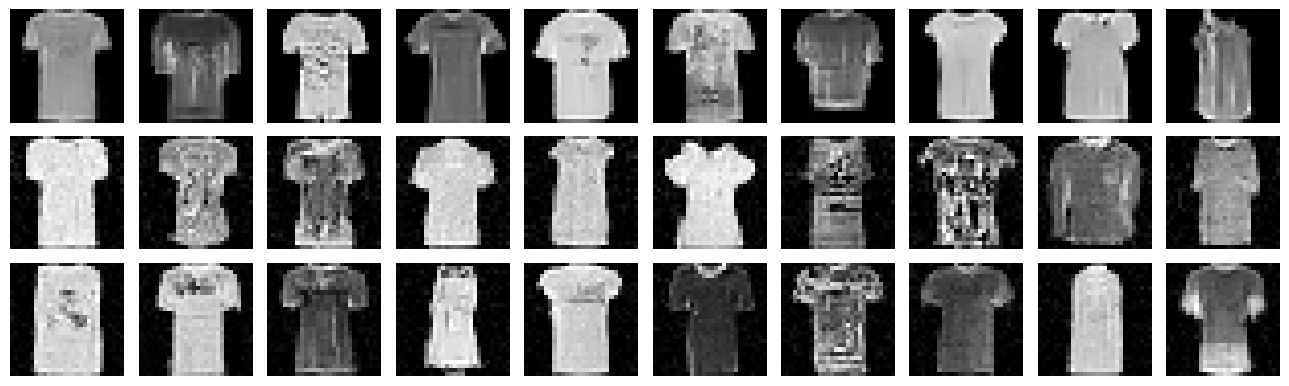

In [14]:
fig, axes = plt.subplots(3,10,figsize=(13,4))
for row, solver in enumerate(["euler","heun","rk4"]):
    samples = sample_cache[(solver,16)].samples[:10]
    for col in range(10):
        axes[row,col].imshow(samples[col,0], cmap="gray", vmin=-1, vmax=1)
        axes[row,col].axis("off")
    axes[row,0].set_ylabel(solver)
plt.tight_layout(); plt.show()

## 14. Training checkpoint × generation time

두 시간축 \(k\) (training)와 \(t\) (generation)을 직접 연결합니다.

,t,velocity_mse,pred_velocity_norm,target_velocity_norm,velocity_cosine,velocity_mse_std,epoch
0,0.05,1.688782,0.000000,36.351007,0.000000,0.148442,0
1,0.15,1.688156,0.000000,36.344805,0.000000,0.147486,0
2,0.25,1.685482,0.000000,36.315138,0.000000,0.148897,0
3,0.35,1.687696,0.000000,36.337974,0.000000,0.150993,0
4,0.45,1.682916,0.000000,36.287504,0.000000,0.148676,0
5,0.55,1.687083,0.000000,36.332075,0.000000,0.149965,0
6,0.65,1.685144,0.000000,36.310646,0.000000,0.150981,0
7,0.75,1.683717,0.000000,36.294964,0.000000,0.151659,0
8,0.85,1.684345,0.000000,36.300303,0.000000,0.154040,0
9,0.95,1.689233,0.000000,36.354519,0.000000,0.151249,0


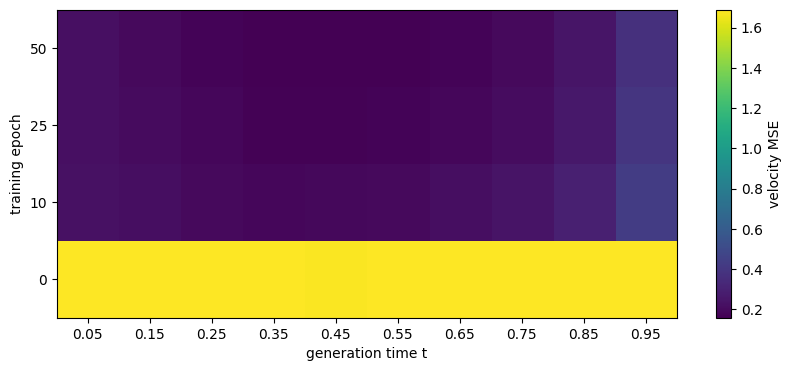

In [15]:
rows = []
for epoch in [0,10,25,50]:
    model.load_state_dict(torch.load(ARTIFACT_DIR/f"dit_epoch_{epoch}.pt", map_location=device))
    df = velocity_diagnostics(model, val_loader, device, T_VALUES, max_batches=4)
    df["epoch"] = epoch
    rows.append(df)
checkpoint_df = pd.concat(rows, ignore_index=True)
display(checkpoint_df.head(15))

heat = checkpoint_df.pivot(index="epoch", columns="t", values="velocity_mse")
plt.figure(figsize=(10,4)); plt.imshow(heat.values, aspect="auto", origin="lower")
plt.colorbar(label="velocity MSE")
plt.xticks(range(len(heat.columns)), [f"{x:.2f}" for x in heat.columns])
plt.yticks(range(len(heat.index)), heat.index)
plt.xlabel("generation time t"); plt.ylabel("training epoch"); plt.show()

# 15. 결과 해석 연쇄

1. timestep-binned loss → 어느 생성 단계가 학습하기 어려운가  
2. velocity/divergence → 그 어려움이 field에 어떻게 나타나는가  
3. layer × timestep representation → field를 만드는 내부 semantic structure는 어디서 형성되는가  
4. Jacobian spectrum → local field geometry는 어떤가  
5. trajectory → field를 실제 적분하면 경로는 어떤 형태인가  
6. solver × NFE → numerical condition이 경로를 어떻게 바꾸는가  
7. generated distribution → 내부 차이가 최종 생성 결과와 연결되는가  
8. checkpoint × timestep → 위 구조가 학습 중 언제 형성되는가

# 16. 기법별 논문 레퍼런스와 활용

| 기법 | 주요 논문 | 논문의 활용 | 노트북 구현 |
|---|---|---|---|
| timestep field dynamics | *Elucidating Flow Matching ODE Dynamics via Data Geometry and Denoisers*, ICML 2025 | FM ODE를 시간별로 분석 | velocity MSE/norm/cosine vs \(t\) |
| divergence | *Improving Flow Matching by Aligning Flow Divergence*, ICML 2025 | velocity divergence로 probability-path alignment 강화 | Hutchinson \(\operatorname{div}v_\theta\) |
| representation dynamics / probe | *Understanding Representation Dynamics of Diffusion Models via Low-Dimensional Modeling*, NeurIPS 2025 | noise level별 representation quality | block × \(t\) linear probe |
| class subspace | 같은 NeurIPS 2025 논문 | class-wise low-dimensional subspace 기반 semantic signal 분석 | PCA class-subspace energy fraction |
| Jacobian local geometry | *Understanding Generalizability of Diffusion Models Requires Rethinking the Hidden Gaussian Structure*, NeurIPS 2024 | denoiser Jacobian singular directions와 data PCA 구조 관계 | velocity Jacobian top singular values |
| low-dimensional diffusion directions | *Exploring Low-Dimensional Subspaces in Diffusion Models*, NeurIPS 2024 | local Jacobian semantic directions | JVP/VJP subspace iteration |
| trajectory regularity | *On the Trajectory Regularity of ODE-based Diffusion Sampling*, ICML 2024 | ODE trajectory shape/regularity | path length, velocity turning |
| straight trajectories | *Optimal Flow Matching*, NeurIPS 2024 | straight transport와 few-step sampling | path-length/displacement + NFE |
| DiT representation | *Representation Alignment for Generation (REPA)*, ICLR 2025 | DiT representation quality/alignment을 생성학습과 연결 | layer별 semantic representation 관찰 |
| final generation | 2024–2026 diffusion/flow 생성 논문 전반 | 내부 분석을 최종 sample quality와 연결 | FashionMNIST feature Fréchet + conditional accuracy |

주요 링크:
- https://proceedings.mlr.press/v267/wan25e.html
- https://proceedings.mlr.press/v267/huang25ag.html
- https://proceedings.neurips.cc/paper_files/paper/2025/hash/9a3b1949b6da9b8facfdc28e1b4722ed-Abstract-Conference.html
- https://proceedings.neurips.cc/paper_files/paper/2024/hash/69e68611ec4d8c0ae4a4b2bece165f5f-Abstract-Conference.html
- https://openreview.net/forum?id=50aOEfb2km
- https://proceedings.mlr.press/v235/chen24bm.html
- https://proceedings.neurips.cc/paper_files/paper/2024/hash/bc8f76d9caadd48f77025b1c889d2e2d-Abstract-Conference.html
- https://openreview.net/forum?id=DJSZGGZYVi

**구분:** timestep probe, divergence, trajectory regularity, Jacobian singular directions는 직접 precedent에 가깝고, class-subspace energy fraction·matched-NFE solver comparison·FashionMNIST feature Fréchet는 작은 T4 실습에 맞춘 축소/가공 구현입니다.